# Nonlinear Joint Offsets

In [1]:
L =  120.0
e = 0 #L/24
P = 2000
E = 29e3
I = 6*12**3/12

ne = 4
Lr = L/20 #L/ne - L/(2*ne)


Create an {ref}`Elastic <ElasticSection>` {py:class}`xara.FrameSection`

In [2]:
import xara

section = xara.FrameSection("Elastic",
    E = E,
    G = 11e3,
    J = 2*12**4/3,
    Iy = I,
    Iz = 6*12**3/12,
    A = 1e3
)

In [3]:
import numpy as np


def create_model_offset(transform, element):

    nn = ne + 1

    model = xara.Model(ndm=3, ndf=6)

    model.section(section)

    for i, y in enumerate(np.linspace(0, L, nn)):
        model.node(i, (0, y, 0))

    # Fix the nodes
    tip = find_node(model, y=L)
    model.fix(0,   (1, 1, 1, 1, 1, 1))
    model.fix(tip, (0, 0, 1, 1, 1, 0))
    # for i in range(1, nn-1):
    #     model.fix(i, (0, 0, 1, 1, 1, 0))


    model.geomTransf(transform, 1, (0, 0, 1))

    model.geomTransf(transform, 2, (0, 0, 1), 
                    jntOffset=(0, 0, 0,   Lr, 0, 0))

    # Create the elements
    for i in range(ne):
        transform = 2 if i == ne-1 else 1
        model.element(element, i, (i, i+1), 
                      section=section, 
                      transform=transform,
                      shear=1)



    #
    # Load
    #
    tip = ne
    base = 0
    model.pattern(
        xara.StaticPattern([
            xara.NodalLoad(model, {tip:  ( 0,-P,0,  0, 0,  P*e,)})
        ])
    )

    return model


## Analysis

In [4]:
from xara.helpers import find_node

def analyze(transform, element):
    n = 80

    # Create model
    model = create_model_offset(transform=transform, element=element)

    Pcr = E*I*np.pi**2/(L*2)**2
    analysis = xara.StaticAnalysis(model, 
                                   test=("Energy", 1e-16, 10, 0),
                                   integrator=("LoadControl", 1/20))

    tip = find_node(model, y=L)
    u, N = [], []
    for i in range(n):
        try:
            analysis.analyze(1)
        except:
            print("\nAnalysis failed at load factor", model.getLoadFactor(1), " step ", i)
            break
        u.append(model.nodeDisp(tip, 6))
        N.append(P*model.getLoadFactor(1)/Pcr)

    return u, N

## Results

In [5]:
import matplotlib.pyplot as plt

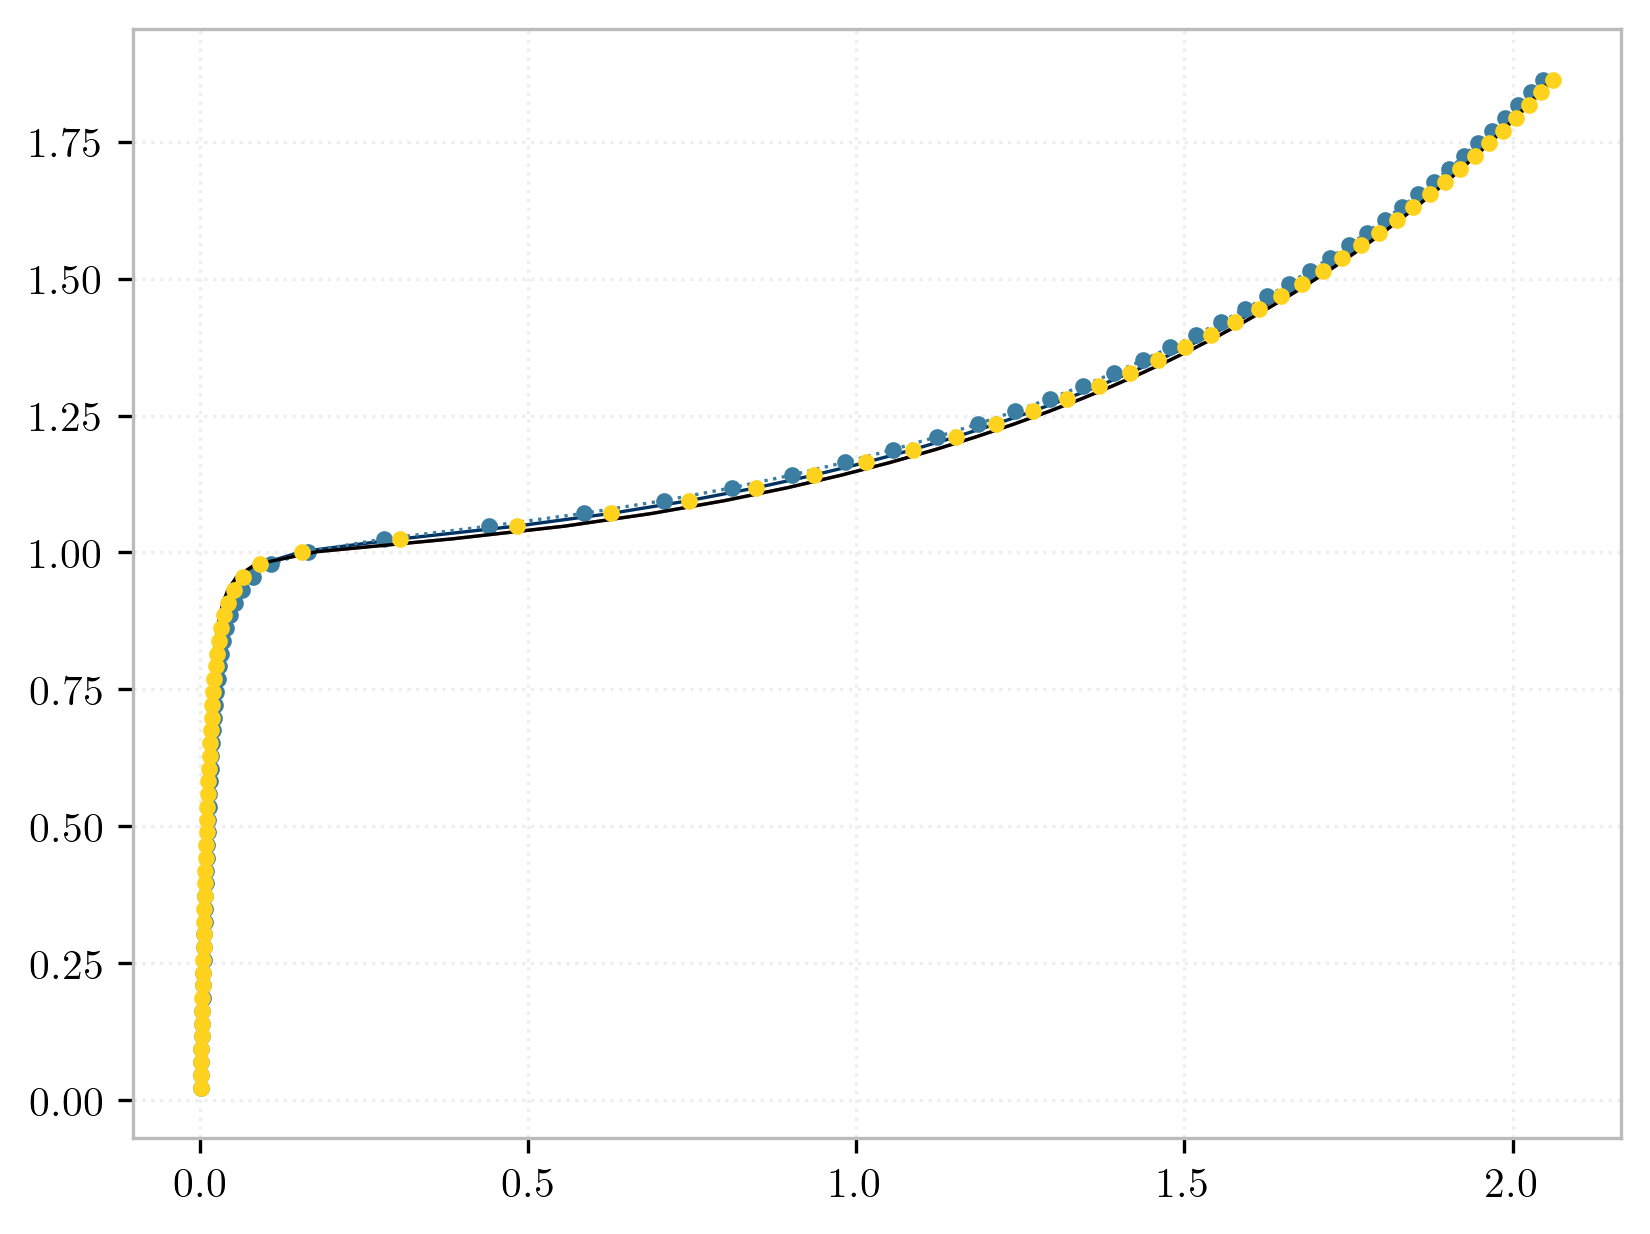

In [7]:
fig, ax = plt.subplots()

ax.plot(*analyze("Spherical",      "CosseratFrame01"))
ax.plot(*analyze("Corotational02", "ForceFrame"))
ax.plot(*analyze("Corotational02", "ShearFrame"), ':.')
ax.plot(*analyze("Corotational02", "ElasticFrame"))
ax.plot(*analyze("Identity",       "CosseratFrame01"), ".")

# ax.plot(*analyze(False,  "Identity",       "CosseratFrame01"), ".")
# ax.plot(*analyze(False,  "Corotational02", "ForceFrame"))
# ax.plot(*analyze(False,  "Spherical",      "CosseratFrame01"))


## References
